# Complete AI Legal Document Analyzer ML + NLP + LegalBERT Pipeline

## Install Libraries

In [6]:
import torch

print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

True
Tesla T4


In [7]:
!pip install transformers datasets accelerate evaluate xgboost seaborn wordcloud -q

## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from datasets import Dataset


## Load Dataset

In [9]:
df = pd.read_csv('/content/sample_data/all_reshaped_clauses.csv')

print(df.head())
print(df.columns)
print(df.shape)


                                            filename        clause_type  \
0  GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...  Change of Control   
1  DeltathreeInc_19991102_S-1A_EX-10.19_6227850_E...  Change of Control   
2  EdietsComInc_20001030_10QSB_EX-10.4_2606646_EX...  Change of Control   
3  MusclepharmCorp_20170208_10-KA_EX-10.38_989358...  Change of Control   
4  TomOnlineInc_20060501_20-F_EX-4.46_749700_EX-4...  Change of Control   

                                         clause_text  
0  For purposes of the preceding sentence, and wi...  
1  The term of this Agreement shall be effective ...  
2  For purposes of this Agreement, "Change in Con...  
3  Neither party shall voluntarily or by operatio...  
4  Notwithstanding the foregoing, Skype or Skype ...  
Index(['filename', 'clause_type', 'clause_text'], dtype='object')
(8628, 3)


## Dataset Information

In [10]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8628 entries, 0 to 8627
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   filename     8628 non-null   object
 1   clause_type  8628 non-null   object
 2   clause_text  8628 non-null   object
dtypes: object(3)
memory usage: 202.3+ KB
None
filename       0
clause_type    0
clause_text    0
dtype: int64


## Data Cleaning

In [11]:
df = df[['clause_text', 'clause_type']]
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(df.shape)


(8041, 2)


## EDA - Clause Distribution

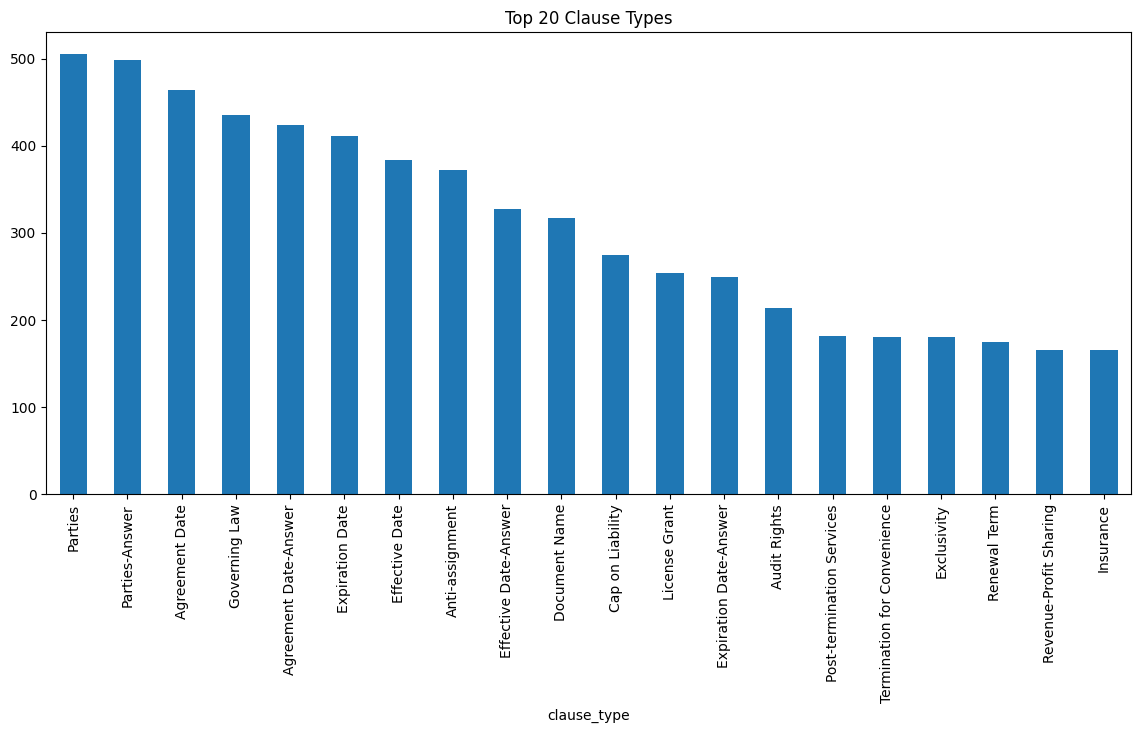

In [12]:
plt.figure(figsize=(14,6))
df['clause_type'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Clause Types')
plt.xticks(rotation=90)
plt.show()


## EDA - Text Length

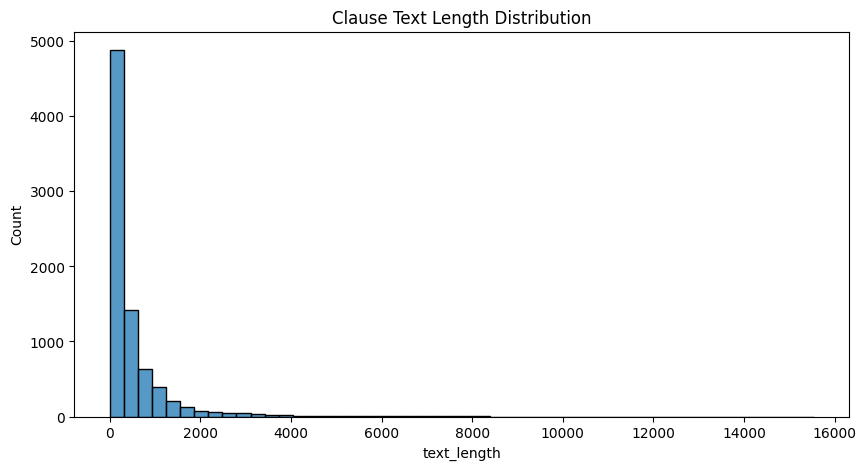

In [13]:
df['text_length'] = df['clause_text'].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=50)
plt.title('Clause Text Length Distribution')
plt.show()


## EDA - Word Cloud

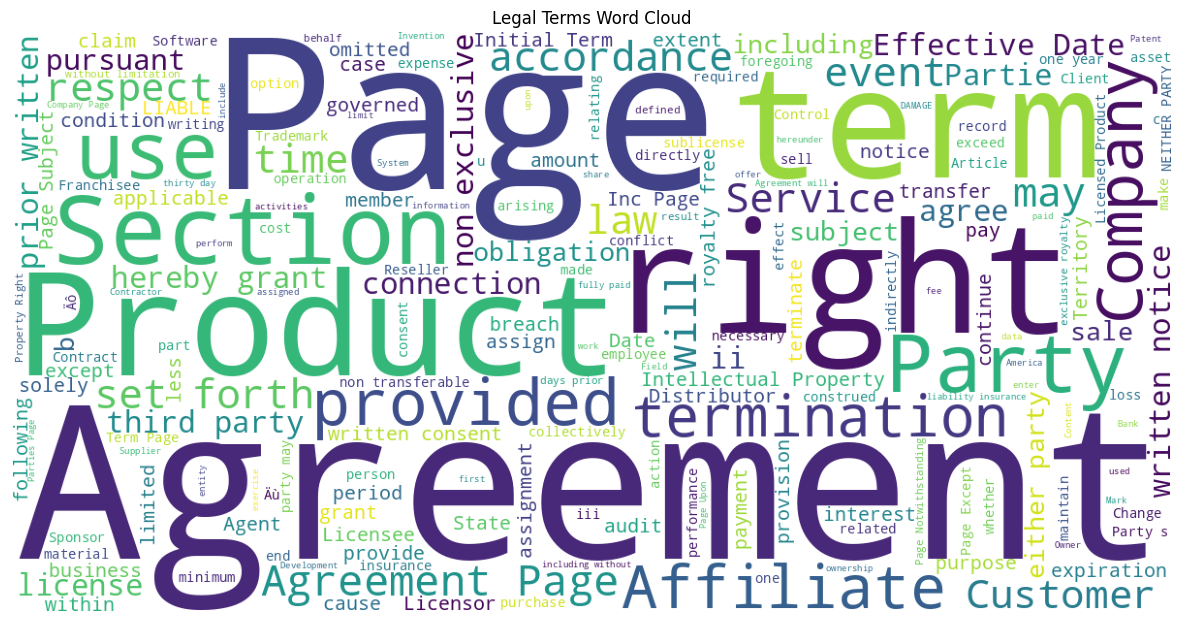

In [14]:
text = ' '.join(df['clause_text'].astype(str).tolist())

wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Legal Terms Word Cloud')
plt.show()


## Feature Engineering

In [15]:
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['clause_type'])

labels = label_encoder.classes_

X = df['clause_text']
y = df['label']


## Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## TF-IDF Vectorization

In [17]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


## Feature Scaling

In [18]:
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_test_scaled = scaler.transform(X_test_tfidf)


## Baseline Models

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Linear SVM': LinearSVC(),
    'Naive Bayes': MultinomialNB()
}

results = []

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)

    f1 = f1_score(y_test, preds, average='weighted')

    results.append([name, acc, f1])

results_df = pd.DataFrame(results, columns=['Model','Accuracy','F1 Score'])

print(results_df)


                 Model  Accuracy  F1 Score
0  Logistic Regression  0.667495  0.633582
1        Random Forest  0.618397  0.600960
2           Linear SVM  0.673710  0.661210
3          Naive Bayes  0.594779  0.516125


## Model Accuracy Graph

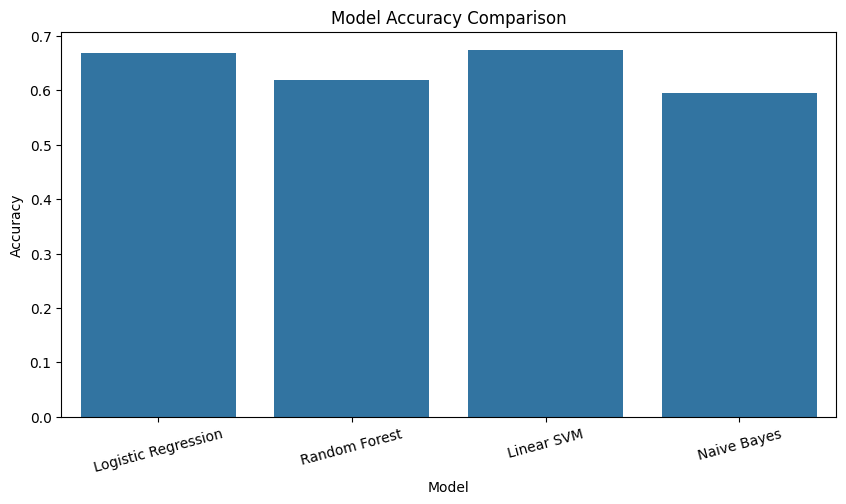

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.show()


## Hyperparameter Tuning

In [21]:
param_grid = {
    'C':[0.1,1,10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train_tfidf, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)


{'C': 10}


## Evaluate Tuned Model

In [22]:
tuned_preds = best_model.predict(X_test_tfidf)

print(classification_report(y_test, tuned_preds))


              precision    recall  f1-score   support

           0       0.29      0.17      0.21        12
           1       0.00      0.00      0.00         5
           2       0.59      0.82      0.68        93
           3       0.39      0.58      0.47        85
           4       0.89      0.95      0.92        75
           5       0.98      0.98      0.98        43
           6       0.66      0.69      0.67        55
           7       0.71      0.62      0.67        24
           8       0.14      0.13      0.14        15
           9       1.00      0.85      0.92        20
          10       0.95      0.95      0.95        63
          11       0.41      0.23      0.30        77
          12       0.12      0.08      0.09        66
          13       0.35      0.39      0.37        36
          14       0.72      0.76      0.74        82
          15       0.50      0.30      0.38        50
          16       1.00      1.00      1.00        87
          17       0.80    

## Confusion Matrix

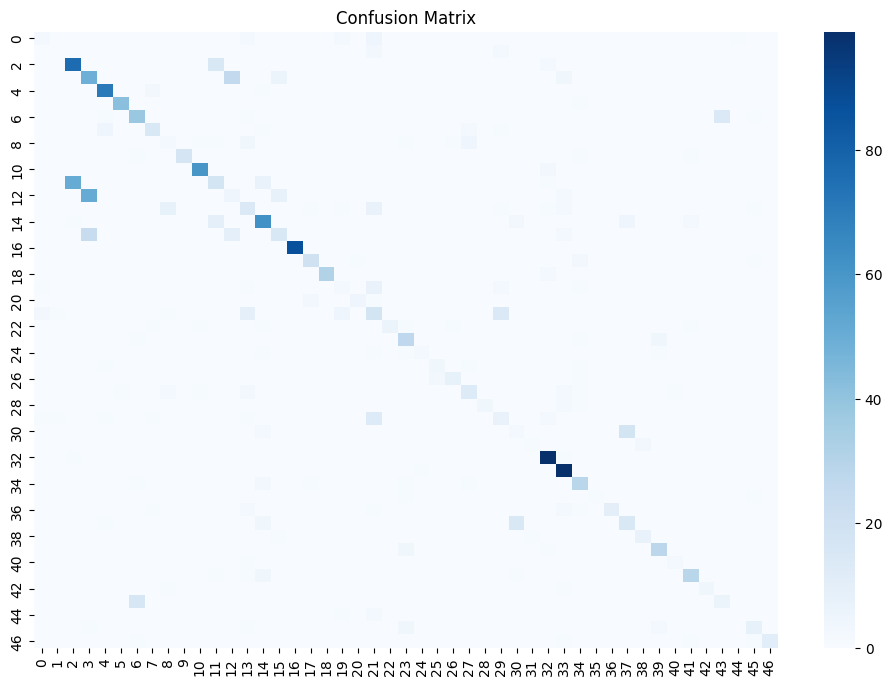

In [23]:
cm = confusion_matrix(y_test, tuned_preds)

plt.figure(figsize=(12,8))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


## Save Traditional ML Pipeline

In [24]:
import joblib

joblib.dump(best_model, 'best_ml_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')


['label_encoder.pkl']

## LegalBERT Setup

In [25]:
MODEL_NAME = "nlpaueb/legal-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## Tokenization

In [26]:
train_texts = X_train.tolist()
test_texts = X_test.tolist()

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=256
    )

train_encodings = tokenize_function(train_texts)
test_encodings = tokenize_function(test_texts)


## Create HuggingFace Dataset

In [27]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': y_train.tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': y_test.tolist()
})


## Load LegalBERT

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels)
)


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were new

## Metrics Function

In [29]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_weighted': f1_score(labels, predictions, average='weighted')
    }


## Training Arguments

In [30]:
training_args = TrainingArguments(
    output_dir='./results',

    num_train_epochs=3,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    warmup_steps=100,

    weight_decay=0.01,

    eval_strategy='epoch',

    save_strategy='epoch',

    load_best_model_at_end=True,

    fp16=torch.cuda.is_available()
)

## Trainer

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)


## Train LegalBERT

In [32]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.860593,0.782462,0.720323,0.661695
2,0.632790,0.644119,0.756370,0.710591
3,0.532945,0.591756,0.761342,0.718663


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2412, training_loss=0.8804288835667852, metrics={'train_runtime': 378.349, 'train_samples_per_second': 51.001, 'train_steps_per_second': 6.375, 'total_flos': 2539521107804160.0, 'train_loss': 0.8804288835667852, 'epoch': 3.0})

## Evaluate LegalBERT

In [33]:
results = trainer.evaluate()
print(results)


{'eval_loss': 0.5917559862136841, 'eval_accuracy': 0.7613424487259167, 'eval_f1_weighted': 0.7186634173169568, 'eval_runtime': 6.7585, 'eval_samples_per_second': 238.072, 'eval_steps_per_second': 29.889, 'epoch': 3.0}


## Save LegalBERT

In [34]:
trainer.save_model('./legalbert_model')
tokenizer.save_pretrained('./legalbert_model')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./legalbert_model/tokenizer_config.json', './legalbert_model/tokenizer.json')

## Inference Pipeline

In [35]:
sample_text = '''
This agreement may terminate immediately if confidentiality terms are violated.
'''

inputs = tokenizer(
    sample_text,
    return_tensors='pt',
    truncation=True,
    padding=True,
    max_length=256
)

if torch.cuda.is_available():
    model.cuda()
    inputs = {k:v.cuda() for k,v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

predicted_label = label_encoder.inverse_transform([pred])[0]

print(predicted_label)


Expiration Date


In [36]:
!zip -r legalbert_model.zip legalbert_model

  adding: legalbert_model/ (stored 0%)
  adding: legalbert_model/model.safetensors (deflated 7%)
  adding: legalbert_model/tokenizer_config.json (deflated 42%)
  adding: legalbert_model/config.json (deflated 69%)
  adding: legalbert_model/tokenizer.json (deflated 71%)
  adding: legalbert_model/training_args.bin (deflated 53%)


In [37]:
from google.colab import files

files.download('legalbert_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>